# VeriFact — Dataset preprocessing

Turning two public benchmarks into one clean, de-duplicated, split dataset for the fake-news ensemble.

| Dataset | Source | What it is |
|---|---|---|
| **LIAR** | Wang (2017), *"Liar, Liar Pants on Fire"*, ACL | 12.8k short political statements from PolitiFact with a 6-point truth rating and speaker metadata |
| **FakeNewsNet** | Shu et al. (2018) | News headlines + source URLs labelled fake/real by **PolitiFact** (politics) and **GossipCop** (entertainment) |

Pipeline: **download → load → clean → label → de-duplicate → split → feature sanity-check → save**.

In [1]:
import sys, json, re
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, str(Path.cwd().parent))
from backend.ml import data
from backend.ml.features import featurize, FEATURE_NAMES
pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.dpi"] = 110
RAW = data.RAW
print("raw data folder:", RAW)

raw data folder: C:\Users\Pranav Bhat\Desktop\hackathonthing\data\raw


## 1. Raw files
`scripts/download_data.py` fetches LIAR (official zip) and the four FakeNewsNet CSVs.

In [2]:
for p in sorted(RAW.rglob("*.*")):
    print(f"{p.relative_to(RAW)!s:40s} {p.stat().st_size/1e6:6.1f} MB")

fakenewsnet\gossipcop_fake.csv             12.5 MB
fakenewsnet\gossipcop_real.csv             20.0 MB
fakenewsnet\politifact_fake.csv             3.3 MB
fakenewsnet\politifact_real.csv             8.3 MB
liar\test.tsv                               0.3 MB
liar\train.tsv                              2.4 MB
liar\valid.tsv                              0.3 MB


### 1a. LIAR — raw TSV (14 columns, no header)

In [3]:
liar_raw = pd.read_csv(RAW/"liar"/"train.tsv", sep="\t", header=None, names=data.LIAR_COLS,
                       quoting=3, dtype=str, keep_default_na=False)
print(liar_raw.shape)
liar_raw.head(3)

(10269, 14)


,id,fine_label,text,subject,speaker,job_title,state,party,barely_true_ct,false_ct,half_true_ct,mostly_true_ct,pants_fire_ct,context
0,2635.json,false,Says the Annies List political group supports third-trimester abortions on demand.,abortion,dwayne-bohac,State representative,Texas,republican,0,1,0,0,0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started when natural gas took off that started to begin in (President George ...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0,0,1,1,0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by voting to give George Bush the benefit of the doubt on Iran.""",foreign-policy,barack-obama,President,Illinois,democrat,70,71,160,163,9,Denver


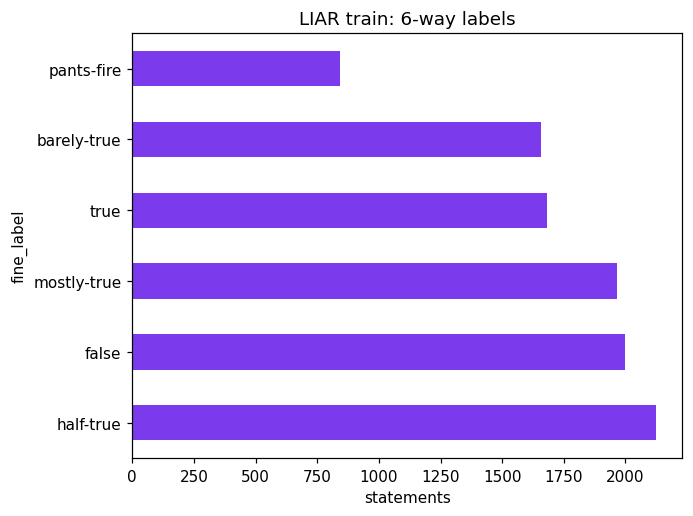

In [4]:
liar_raw["fine_label"].value_counts().plot(kind="barh", color="#7c3aed", title="LIAR train: 6-way labels");
plt.xlabel("statements"); plt.tight_layout()

### 1b. FakeNewsNet — raw CSVs (`id, news_url, title, tweet_ids`)

In [5]:
fnn_raw = pd.read_csv(RAW/"fakenewsnet"/"politifact_fake.csv", dtype=str, keep_default_na=False)
print(fnn_raw.shape); fnn_raw[["id","news_url","title"]].head(3)

(432, 4)


,id,news_url,title
0,politifact15014,speedtalk.com/forum/viewtopic.php?t=51650,BREAKING: First NFL Team Declares Bankruptcy Over Kneeling Thugs
1,politifact15156,politics2020.info/index.php/2018/03/13/court-orders-obama-to-pay-400-million-in-restitution/,Court Orders Obama To Pay $400 Million In Restitution
2,politifact14745,www.nscdscamps.org/blog/category/parenting/467344/update-second-roy-moore-accuser-works-for-michelle-obama-right-now...,UPDATE: Second Roy Moore Accuser Works For Michelle Obama Right NOW -


## 2. Cleaning & unification

Decisions (implemented in `backend/ml/data.py` so training and the API share one code path):

* **Text cleaning** — collapse whitespace; keep casing and punctuation (shouting and `!!!` are *signal* for the style features).
* **LIAR binarisation** — `pants-fire / false / barely-true → fake (1)`, `half-true / mostly-true / true → real (0)` (standard in the literature).
* **FakeNewsNet** — the `title` is the text; the `news_url` is parsed to a bare domain which later feeds the source-credibility agent.
* **Drop** empty rows and titles shorter than 10 characters (ids/garbage); **de-duplicate** on exact text.
* **Splits** — LIAR keeps its *official* train/valid/test; FakeNewsNet is split 80/10/10 **stratified per source** so every source appears in test.

In [6]:
df = data.load_unified(cache=False)
print(df.shape)
df.sample(6, random_state=3)[["text","label","fine_label","dataset","domain","split"]]

(34534, 10)


,text,label,fine_label,dataset,domain,split
1822,Says President Barack Obama is the first president weve ever had who thinks he can choose which laws to enforce and ...,1,false,liar,,train
24015,"'Stranger Things' Creators Respond to Claims of Verbal ""Abuse"" by Former Crewmember",0,real,gossipcop,hollywoodreporter.com,train
31291,Gal Gadot reacts to Wonder Woman Oscars snub,0,real,gossipcop,ew.com,train
32238,"Meghan Markle Says Her Bachelorette Party Is Already ""Sorted""",0,real,gossipcop,brides.com,test
31634,See Margot Robbie Transform as Queen Elizabeth I in Mary Queen of Scots Scene,0,real,gossipcop,people.com,test
11321,"If Florida had not taken the stimulus, it would have led to the firing of 20,000 teachers.",0,mostly-true,liar,,valid


## 3. Dataset composition

In [7]:
summary = data.summary(df)
print(json.dumps(summary, indent=2))

{
  "total": 34534,
  "fake_share": 0.3178606590606359,
  "gossipcop": {
    "rows": 20741,
    "fake": 4895,
    "real": 15846,
    "splits": {
      "train": 16592,
      "test": 2075,
      "valid": 2074
    }
  },
  "liar": {
    "rows": 12810,
    "fake": 5654,
    "real": 7156,
    "splits": {
      "train": 10252,
      "valid": 1279,
      "test": 1279
    }
  },
  "politifact": {
    "rows": 983,
    "fake": 428,
    "real": 555,
    "splits": {
      "train": 786,
      "test": 99,
      "valid": 98
    }
  }
}


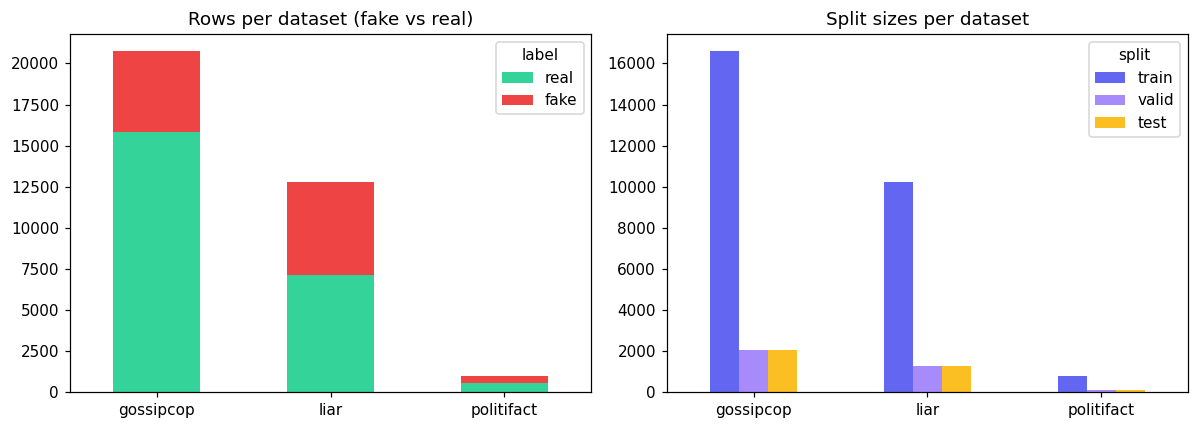

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
comp = df.groupby(["dataset","label"]).size().unstack(fill_value=0).rename(columns={0:"real",1:"fake"})
comp.plot(kind="bar", stacked=True, ax=ax[0], color=["#34d399","#ef4444"], title="Rows per dataset (fake vs real)")
ax[0].set_xlabel(""); ax[0].tick_params(axis="x", rotation=0)
df.groupby(["dataset","split"]).size().unstack(fill_value=0)[["train","valid","test"]].plot(
    kind="bar", ax=ax[1], title="Split sizes per dataset", color=["#6366f1","#a78bfa","#fbbf24"])
ax[1].set_xlabel(""); ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout()

Class balance is **32 % fake overall** but differs by source — the models use class weights so GossipCop's 76 % real share does not swamp the LIAR signal.

## 4. Text length

,mean,50%,max
dataset,,,
gossipcop,11.342751,11.0,39.0
liar,17.931069,17.0,66.0
politifact,9.759919,9.0,53.0


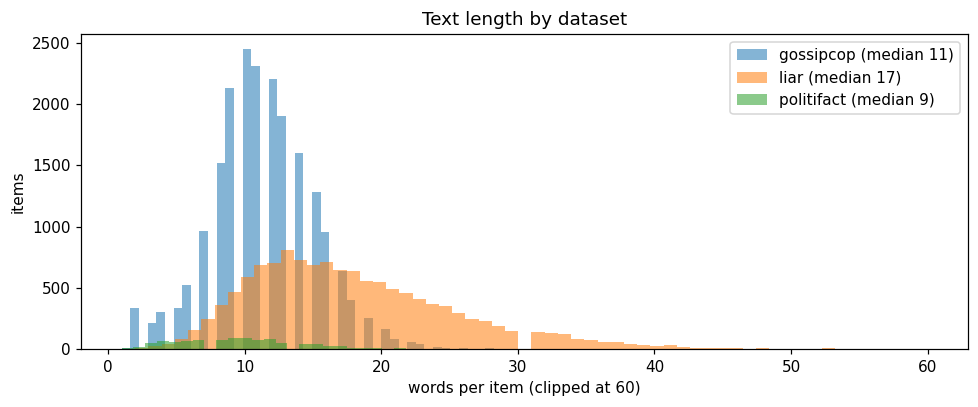

In [9]:
df["n_words"] = df["text"].str.split().str.len()
fig, ax = plt.subplots(figsize=(9, 3.8))
for name, g in df.groupby("dataset"):
    ax.hist(g["n_words"].clip(upper=60), bins=60, alpha=0.55, label=f"{name} (median {int(g['n_words'].median())})")
ax.set_xlabel("words per item (clipped at 60)"); ax.set_ylabel("items"); ax.legend(); ax.set_title("Text length by dataset")
plt.tight_layout()
df.groupby("dataset")["n_words"].describe()[["mean","50%","max"]]

Items are short (median 11–18 words) → `max_len=64` tokens for DistilBERT loses nothing, and long articles at inference are scored as *lead + body chunks* (see `agents/graph.py`).

## 5. Source domains (FakeNewsNet)
The domain column is also aggregated into `models/domain_stats.json` — a per-domain fake rate the credibility agent consults.

In [10]:
dom = df[df["domain"] != ""].groupby("domain")["label"].agg(fake="sum", total="count")
dom["fake_rate"] = dom["fake"] / dom["total"]
top = dom[dom["total"] >= 30].sort_values("total", ascending=False).head(15)
top.style.format({"fake_rate": "{:.0%}"}).background_gradient(subset=["fake_rate"], cmap="Reds")

,fake,total,fake_rate
domain,,,
people.com,193,1633,12%
dailymail.co.uk,183,919,20%
usmagazine.com,129,659,20%
etonline.com,66,634,10%
longroom.com,0,562,0%
en.wikipedia.org,93,536,17%
hollywoodlife.com,413,477,87%
hollywoodreporter.com,32,308,10%
usatoday.com,32,300,11%


## 6. Stylistic features — do they separate the classes?
23 hand-crafted features (`backend/ml/features.py`) capture *how* something is written, independent of topic.

In [11]:
sample = df.sample(6000, random_state=0)
F = pd.DataFrame(featurize(sample["text"]), columns=FEATURE_NAMES)
F["label"] = sample["label"].values
means = F.groupby("label").mean().T.rename(columns={0:"real",1:"fake"})
means["ratio fake/real"] = (means["fake"] + 1e-6) / (means["real"] + 1e-6)
means.sort_values("ratio fake/real", ascending=False).head(10).style.format("{:.3f}")

label,real,fake,ratio fake/real
percent_signs,0.002,0.004,2.500
question,0.032,0.068,2.138
negations,0.004,0.008,2.080
hedge_hits,0.034,0.069,2.016
clickbait_hits,0.041,0.065,1.580
ellipsis,0.017,0.019,1.126
pron_1_2,0.011,0.012,1.087
n_chars,81.043,87.025,1.074
n_words,13.296,14.260,1.073
long_word_ratio,0.156,0.160,1.030


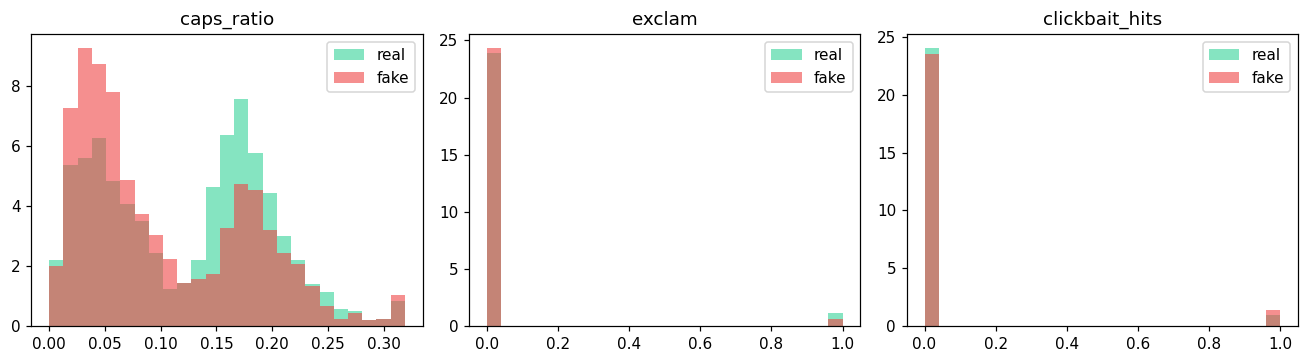

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
for a, col in zip(ax, ["caps_ratio", "exclam", "clickbait_hits"]):
    for lab, color in ((0, "#34d399"), (1, "#ef4444")):
        a.hist(F[F.label == lab][col].clip(upper=F[col].quantile(0.99)), bins=25, alpha=0.6,
               density=True, color=color, label="real" if lab == 0 else "fake")
    a.set_title(col); a.legend()
plt.tight_layout()

## 7. Leakage & sanity checks

In [13]:
tr = set(df[df.split=="train"]["text"]); te = set(df[df.split=="test"]["text"]); va = set(df[df.split=="valid"]["text"])
print("train∩test overlap:", len(tr & te), "| train∩valid:", len(tr & va), "| duplicates:", df["text"].duplicated().sum())
print("empty texts:", (df["text"].str.len()==0).sum(), "| label values:", sorted(df["label"].unique()))
assert not (tr & te) and not df["text"].duplicated().any()

train∩test overlap: 0 | train∩valid: 0 | duplicates: 0
empty texts: 0 | label values: [np.int64(0), np.int64(1)]


## 8. Saved artefact
`data/processed/unified.parquet` is what `backend/ml/train.py` consumes. Columns:

In [14]:
df.drop(columns="n_words").dtypes

text          object
label          int64
fine_label    object
dataset       object
domain        object
split         object
speaker       object
party         object
context       object
subject       object
dtype: object

## Summary

* **34,534** unique labelled items from 3 sources, **32 % fake**, zero train/test overlap.
* Unified binary label, original fine labels preserved for analysis.
* Official LIAR splits + stratified FakeNewsNet splits → honest, comparable evaluation.
* Domain table and stylistic features derived here are reused by the serving pipeline.

Next: `02_model_training` — TF-IDF+LR, MiniLM+XGBoost, DistilBERT, stacked ensemble (`python -m backend.ml.train all`).